In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#9.1

A = np.random.normal(10, 4, size=(3, 3))
Q, R = np.linalg.qr(A)
Q.T @ Q, Q @ Q.T, Q @ np.linalg.inv(Q), np.linalg.inv(Q) @ Q

(array([[ 1.00000000e+00, -1.80487012e-17,  1.95720699e-16],
        [-1.80487012e-17,  1.00000000e+00,  4.21251371e-17],
        [ 1.95720699e-16,  4.21251371e-17,  1.00000000e+00]]),
 array([[ 1.00000000e+00, -1.60870789e-17,  1.18981150e-16],
        [-1.60870789e-17,  1.00000000e+00, -7.63406756e-17],
        [ 1.18981150e-16, -7.63406756e-17,  1.00000000e+00]]),
 array([[ 1.00000000e+00,  3.94240723e-17,  7.95884786e-18],
        [ 3.08632639e-17,  1.00000000e+00, -4.85851000e-17],
        [-3.50062448e-19, -2.08295244e-17,  1.00000000e+00]]),
 array([[ 1.00000000e+00,  2.66109525e-18, -1.33594624e-17],
        [ 3.11989298e-17,  1.00000000e+00, -8.60160641e-17],
        [ 2.91872453e-17, -6.88971654e-17,  1.00000000e+00]]))

In [4]:
#9.2

np.random.seed(0)

def gs(A):

    Q = A.copy()

    for col in range(0, Q.shape[1]):
        pred = Q[:,0:col] if Q[:,0:col].shape[1] > 0 else np.zeros(Q.shape[0]).reshape(Q.shape[0],1)
        Q[:, col] = (Q[:, col] - np.sum((Q[:, col].T @ pred) * pred, axis=1)) 
        Q[:, col] /= np.linalg.norm(Q[:, col])

    R = Q.T @ A

    return [Q, R]

A = np.float32(np.random.randint(1, 50, size=(3, 3)))
print(A)
Q, R = gs(A)
gs(Q)[0].T @ Q

    

[[45. 48.  1.]
 [ 4.  4. 40.]
 [10. 20. 22.]]


array([[ 1.0000000e+00,  3.6388440e-07, -1.4727613e-07],
       [ 8.6343608e-09,  1.0000001e+00, -1.7253532e-07],
       [ 5.4960003e-10, -2.4520705e-09,  1.0000001e+00]], dtype=float32)

In [5]:
#9.3

U, R1 = np.linalg.qr(np.random.randint(1, 100, size=(6, 6)))

U = U * np.arange(10, 16)
U[1, 4] = 0
Q, R = gs(U)
R

array([[ 1.00000000e+01,  6.77921595e-16, -3.95976162e-16,
         1.91502085e-16,  1.20262858e+00, -4.97393860e-17],
       [-2.12775544e-16,  1.10000000e+01,  1.28870307e-15,
        -3.83754053e-15, -1.33811285e-01, -2.61450824e-15],
       [ 3.53776678e-16, -3.72227152e-16,  1.20000000e+01,
         1.26531849e-15, -8.27306397e-01,  2.65416801e-17],
       [-5.56521984e-17,  2.66838220e-16, -2.18389401e-16,
         1.30000000e+01,  2.08571418e+00, -3.89712957e-15],
       [ 3.82263718e-16,  6.63925065e-17, -1.69968809e-16,
         6.24039973e-17,  1.34741701e+01,  1.18167778e+00],
       [ 4.03370428e-16, -4.68403664e-16,  2.10977706e-16,
        -1.61531664e-16, -7.28207744e-17,  1.49533821e+01]])

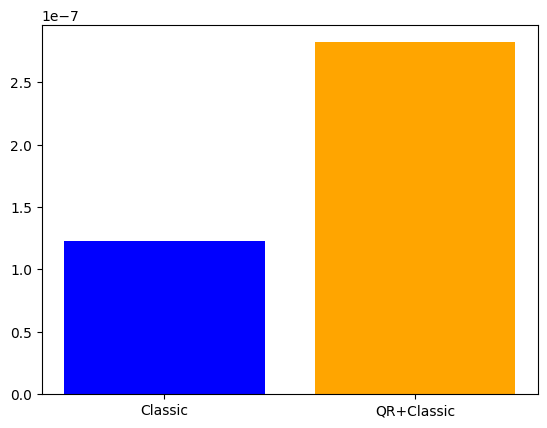

1.228781230931777e-07 2.8204162762683183e-07


In [6]:
#9.4
def obr(A):
    A_transform = A.copy()
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            A_transform[i, j] = np.round(np.linalg.det(np.delete(np.delete(A, i, axis=0), j, axis=1)))

    grid = (-1) ** (np.arange(A_transform.shape[0])[:, np.newaxis] + np.arange(A_transform.shape[1]))
    A_transform *= grid
    A_inv = (np.linalg.det(A) ** -1) * A_transform.T 
    return A_inv

A = np.float32(np.random.randint(1, 10, size=(3, 3)))

res1 = obr(A) @ A 

Q, R = gs(A)

res2 = A @ (np.linalg.inv(R) @ Q.T)

distance1 = np.sqrt(np.sum((res1 - np.eye(3, 3))**2))
distance2 = np.sqrt(np.sum((res2 - np.eye(3, 3))**2))


categ = ['Classic', 'QR+Classic']
values = [distance1, distance2]
plt.bar(categ, values, color=['blue', 'orange'])
plt.show()
print(distance1, distance2)

In [7]:
#9.5 ---skip

In [71]:
#9.6 
Q, R = gs(np.random.randn(100).reshape(10, 10))
#9.6.1
print(np.linalg.norm(Q)/np.sqrt(10), '\n', np.sqrt(np.sum(Q**2))/np.sqrt(10))
#9.6.2
v = np.random.randn(10).reshape(10, 1)
np.linalg.norm(Q @ v), np.linalg.norm(v)

1.0 
 1.0


(np.float64(2.84119172549235), np.float64(2.8411917254923504))

In [90]:
#9.7

A = np.random.randn(16).reshape(8, 2)
Q, R = np.linalg.qr(A, 'complete')
np.linalg.pinv(R) @ R

array([[ 1.00000000e+00,  2.14289547e-17],
       [-3.67042392e-18,  1.00000000e+00]])